In [ ]:
# Add algorithm directory to path to import local modules if needed
import sys
import pandas as pd
import os
import numpy as np
sys.path.append(os.path.abspath("algorithm"))
from pathlib import Path
import sys

ROOT = Path("..") if Path("../configs").exists() else Path(".")
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT))

from src.hcm_transcription.mapping import MAPPING
from src.hcm_transcription.utils import ORNAMENT_MAPPING, df_to_anno

In [3]:
def extract_ornament_segments(raga_names, data_home, annotation_base="Ornamentation-In-Hindustani-Vocals-Dataset"):

    TARGET_LABELS = {"Kan", "Meend", "Murki", "Andolan"}
    segments = []

    for raga_name in raga_names:
        if raga_name not in MAPPING:
            print(f"Skipping {raga_name} - not in MAPPING")
            continue

        data = MAPPING[raga_name]
        annotation_file = f"{annotation_base}/{list(data['annotators'].values())[0]}"

        # Build pitch path directly from audio_path — no compiam needed
        pitch_path = f"{data_home}/saraga1.5_hindustani/{data['audio_path'].replace(' : ', ' _ ')}.pitch.txt"

        print(f"Loading {raga_name}...")
        print(f"  Pitch: {pitch_path}")

        if not os.path.exists(pitch_path):
            print(f"  WARNING: pitch file not found, skipping")
            continue

        if not os.path.exists(annotation_file):
            print(f"  WARNING: annotation file not found, skipping")
            continue
        # Load pitch data
        df_pitch = pd.read_csv(pitch_path, sep="\t", header=None)
        df_pitch.columns = ["time", "f0"]
        df_pitch["log_f0"] = df_pitch["f0"].apply(lambda x: np.log2(x) if x > 0 else np.nan)

        # Load annotations
        df_raw = pd.read_csv(annotation_file, header=None)
        anno = df_to_anno(df_raw)

        # Filter to target labels only
        anno_filtered = anno[anno['label'].isin(TARGET_LABELS)].reset_index(drop=True)
        print(f"  Found {len(anno_filtered)} target ornaments out of {len(anno)} total")

        for _, row in anno_filtered.iterrows():
            mask = (df_pitch["time"] >= row['time_s']) & (df_pitch["time"] <= row['time_e'])
            segment_pitch = df_pitch[mask]["log_f0"].values

            if len(segment_pitch) == 0 or np.isnan(segment_pitch).mean() > 0.3:
                continue

            segment_pitch = pd.Series(segment_pitch).interpolate().fillna(0).values

            segments.append({
                "raga": raga_name,
                "label": row['label'],
                "time_s": row['time_s'],
                "time_e": row['time_e'],
                "duration": row['duration'],
                "pitch_curve": segment_pitch
            })

    # Summary
    df_segments = pd.DataFrame([{k: v for k, v in s.items() if k != "pitch_curve"} 
                                  for s in segments])
    print(f"\n=== Extraction Summary ===")
    print(f"Total segments: {len(segments)}")
    print(f"Label distribution:\n{df_segments['label'].value_counts()}")
    print(f"Duration stats:\n{df_segments['duration'].describe()}")

    return segments

In [4]:
raga_names = ["Aahir Bhairon", "Bairagi", "Bhairavi Dadra", "Irani Bhairavi Thumri", "Kalavati", "Malkauns", "Chandrakauns",  "Majh Khamaj Thumri"
              "Nat Bhairon", "Raageshree", "Todi"]  # whatever is in your MAPPING
data_home = r"C:\Users\despn\Downloads\MIR"
annotation_base = r"C:\Users\despn\Downloads\MIR\hindustani-ornamentation-classification\ornament_classification\Ornamentation-In-Hindustani-Vocals-Dataset"

segments = extract_ornament_segments(raga_names, data_home, annotation_base)

# Inspect one segment
print(segments[0]['label'])
print(segments[0]['pitch_curve'])

Loading Aahir Bhairon...
  Pitch: C:\Users\despn\Downloads\MIR/saraga1.5_hindustani/Geetinandan _ Part-3 by Ajoy Chakrabarty/Aahir Bhairon/Aahir Bhairon.pitch.txt
  Found 109 target ornaments out of 149 total
Loading Bairagi...
  Pitch: C:\Users\despn\Downloads\MIR/saraga1.5_hindustani/New Signature by Brajeshwar Mukherjee/Raag Bairagi/Raag Bairagi.pitch.txt
  Found 65 target ornaments out of 89 total
Loading Bhairavi Dadra...
  Pitch: C:\Users\despn\Downloads\MIR/saraga1.5_hindustani/Raag Bihag & Bhairavi Dadra by Omkar Dadarkar/Bhairavi Dadra/Bhairavi Dadra.pitch.txt
  Found 23 target ornaments out of 67 total
Loading Irani Bhairavi Thumri...
  Pitch: C:\Users\despn\Downloads\MIR/saraga1.5_hindustani/New Signature by Brajeshwar Mukherjee/Irani Bhairavi Thumri/Irani Bhairavi Thumri.pitch.txt
  Found 83 target ornaments out of 103 total
Loading Kalavati...
  Pitch: C:\Users\despn\Downloads\MIR/saraga1.5_hindustani/Geetinandan _ Part-3 by Ajoy Chakrabarty/Kalavati/Kalavati.pitch.txt
  F

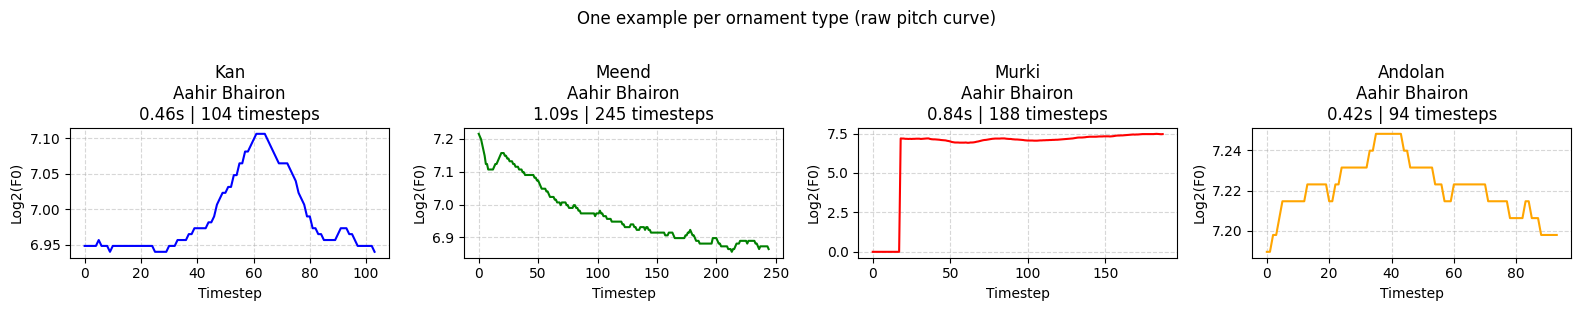

In [25]:
# Plot one example per class
fig, axes = plt.subplots(1, 4, figsize=(16, 3))
colors = {"Kan": "blue", "Meend": "green", "Murki": "red", "Andolan": "orange"}

for ax, label in zip(axes, ["Kan", "Meend", "Murki", "Andolan"]):
    # Find first example of this label
    example = next((s for s in segments if s['label'] == label), None)
    
    if example is None:
        ax.set_title(f"{label}\n(not found)")
        continue
    
    curve = example['pitch_curve']
    ax.plot(curve, color=colors[label], linewidth=1.5)
    ax.set_title(f"{label}\n{example['raga']}\n{example['duration']:.2f}s | {len(curve)} timesteps")
    ax.set_xlabel("Timestep")
    ax.set_ylabel("Log2(F0)")
    ax.grid(True, linestyle='--', alpha=0.5)

plt.suptitle("One example per ornament type (raw pitch curve)", y=1.02)
plt.tight_layout()
plt.show()

In [26]:
import pandas as pd

# Build summary dataframe
df_segments = pd.DataFrame([{k: v for k, v in s.items() if k != "pitch_curve"} for s in segments])
df_segments['num_timesteps'] = [len(s['pitch_curve']) for s in segments]

print("=== Class Distribution ===")
print(df_segments['label'].value_counts())

print("\n=== Duration Stats per Class (seconds) ===")
print(df_segments.groupby('label')['duration'].describe().round(3))

print("\n=== Timestep Stats per Class ===")
print(df_segments.groupby('label')['num_timesteps'].describe().round(1))

print("\n=== Duration Stats per Raga ===")
print(df_segments.groupby('raga')['duration'].describe().round(3))

=== Class Distribution ===
label
Meend      278
Kan        231
Murki      117
Andolan     24
Name: count, dtype: int64

=== Duration Stats per Class (seconds) ===
         count   mean    std    min    25%    50%    75%    max
label                                                          
Andolan   24.0  0.721  0.664  0.107  0.274  0.348  1.171  2.204
Kan      231.0  0.411  0.318  0.065  0.197  0.292  0.551  1.976
Meend    278.0  0.732  0.414  0.174  0.478  0.628  0.868  4.040
Murki    117.0  1.023  0.752  0.017  0.438  0.797  1.378  4.060

=== Timestep Stats per Class ===
         count   mean    std   min    25%    50%    75%    max
label                                                         
Andolan   24.0  162.2  149.4  24.0   60.8   78.5  263.5  497.0
Kan      231.0   92.4   71.6  14.0   44.0   65.0  124.0  445.0
Meend    278.0  164.7   93.3  39.0  107.0  141.5  195.2  909.0
Murki    117.0  230.2  169.2   4.0   99.0  179.0  310.0  913.0

=== Duration Stats per Raga ===
        

In [25]:
lengths = [len(s['pitch_curve']) for s in segments]
print(f"min: {min(lengths)}")
print(f"max: {max(lengths)}")
print(f"mean: {np.mean(lengths):.0f}")
print(f"95th percentile: {np.percentile(lengths, 95):.0f}")

min: 4
max: 1045
mean: 146
95th percentile: 371


In [27]:
def augment_pitch_curve(curve, noise_std=0.01, stretch_range=(0.8, 1.2)):
    """
    Applies random augmentations to a pitch curve:
    - Gaussian noise
    - Time stretching (resampling)
    """
    from scipy.signal import resample
    
    # Random time stretch
    stretch_factor = np.random.uniform(*stretch_range)
    new_length = int(len(curve) * stretch_factor)
    curve = resample(curve, new_length)
    
    # Add small Gaussian noise
    #curve = curve + np.random.normal(0, noise_std, len(curve))
    
    return curve


def augment_segments(segments, num_augmentations=2):
    """
    Augments each segment num_augmentations times and adds to dataset.
    """
    augmented = []
    for seg in segments:
        augmented.append(seg)  # keep original
        
        for _ in range(num_augmentations):
            aug_curve = augment_pitch_curve(seg['pitch_curve'].copy())
            augmented.append({
                "raga": seg['raga'],
                "label": seg['label'],
                "time_s": seg['time_s'],
                "time_e": seg['time_e'],
                "duration": seg['duration'],
                "pitch_curve": aug_curve
            })
    
    print(f"Original: {len(segments)} → Augmented: {len(augmented)} segments")
    return augmented

segments_aug = augment_segments(segments, num_augmentations=2)

Original: 650 → Augmented: 1950 segments


### Preprocess

In [28]:
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

def prepare_tcn_input(segments, fixed_length=117):
    """
    Takes raw segments from extract_ornament_segments and prepares
    fixed-length numpy arrays for TCN training.
    """
    label_map = {"Kan": 0, "Meend": 1, "Murki": 2, "Andolan": 3}
    
    X, y = [], []
    skipped = 0

    # Filter too-short segments before processing
    segments = [s for s in segments if len(s['pitch_curve']) >= 20]
    
    for seg in segments:
        curve = seg['pitch_curve']
        label = seg['label']
        
        if label not in label_map:
            skipped += 1
            continue
        
        # Normalize each curve to zero mean and unit variance
        if curve.std() > 0:
            curve = (curve - curve.mean()) / curve.std()
        
        # Pad or truncate to fixed length
        if len(curve) < fixed_length:
            curve = np.pad(curve, (0, fixed_length - len(curve)), mode='constant')
        else:
            curve = curve[:fixed_length]
        
        X.append(curve)
        y.append(label_map[label])
    
    X = np.array(X, dtype=np.float32)[:, np.newaxis, :]  # (N, 1, fixed_length)
    y = np.array(y, dtype=np.int64)
    
    print(f"X shape: {X.shape}")
    print(f"y shape: {y.shape}")
    print(f"Skipped: {skipped}")
    print(f"Label distribution: { {k: int((y==v).sum()) for k,v in label_map.items()} }")
    
    return X, y, label_map


def get_dataloaders(X, y, batch_size=16, test_size=0.2):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )
    
    train_ds = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
    test_ds  = TensorDataset(torch.tensor(X_test),  torch.tensor(y_test))
    
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size)
    
    print(f"Train: {len(train_ds)} | Test: {len(test_ds)}")
    return train_loader, test_loader

In [29]:
import torch.nn as nn

class ResidualBlock(nn.Module):
    def __init__(self, channels, kernel_size, dilation):
        super().__init__()
        padding = (kernel_size - 1) * dilation
        self.conv1 = nn.Conv1d(channels, channels, kernel_size, dilation=dilation, padding=padding)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size, dilation=dilation, padding=padding)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        self.norm1 = nn.BatchNorm1d(channels)
        self.norm2 = nn.BatchNorm1d(channels)

    def forward(self, x):
        out = self.relu(self.norm1(self.conv1(x)[:, :, :x.size(2)]))
        out = self.dropout(out)
        out = self.relu(self.norm2(self.conv2(out)[:, :, :x.size(2)]))
        return self.relu(out + x)  # residual connection


class OrnamentTCN(nn.Module):
    def __init__(self, input_size=1, num_classes=4, channels=32, kernel_size=3):
        super().__init__()
        self.input_proj = nn.Conv1d(input_size, channels, kernel_size=1)
        self.tcn = nn.Sequential(
            ResidualBlock(channels, kernel_size, dilation=1),
            ResidualBlock(channels, kernel_size, dilation=2),
            ResidualBlock(channels, kernel_size, dilation=4),
            ResidualBlock(channels, kernel_size, dilation=8),
        )
        self.adaptive_pool = nn.AdaptiveAvgPool1d(1)  # collapses any length to 1
        self.classifier = nn.Linear(channels, num_classes)

    def forward(self, x):
        out = self.input_proj(x)
        out = self.tcn(out)
        out = out.mean(dim=2)  # global average pooling
        return self.classifier(out)

In [30]:
from sklearn.utils.class_weight import compute_class_weight

def train_tcn(train_loader, test_loader, num_classes=4, epochs=30):
    model = OrnamentTCN(input_size=1, num_classes=num_classes)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    
    # Handle class imbalance
    all_labels = train_loader.dataset.tensors[1].numpy()
    weights = compute_class_weight('balanced', classes=np.unique(all_labels), y=all_labels)
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float))
    
    for epoch in range(epochs):
        # Train
        model.train()
        train_loss, correct, total = 0, 0, 0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            correct += (preds.argmax(1) == yb).sum().item()
            total += len(yb)
        
        # Evaluate
        model.eval()
        test_correct, test_total = 0, 0
        with torch.no_grad():
            for xb, yb in test_loader:
                preds = model(xb)
                test_correct += (preds.argmax(1) == yb).sum().item()
                test_total += len(yb)
        
        print(f"Epoch {epoch+1:02d} | "
              f"Loss: {train_loss/len(train_loader):.4f} | "
              f"Train Acc: {correct/total:.3f} | "
              f"Test Acc: {test_correct/test_total:.3f}")
    
    return model

In [31]:
# After running extract_ornament_segments
X, y, label_map = prepare_tcn_input(segments_aug, fixed_length=200)
train_loader, test_loader = get_dataloaders(X, y, batch_size=16)
model = train_tcn(train_loader, test_loader, epochs=30)

X shape: (1941, 1, 200)
y shape: (1941,)
Skipped: 0
Label distribution: {'Kan': 687, 'Meend': 834, 'Murki': 348, 'Andolan': 72}
Train: 1552 | Test: 389
Epoch 01 | Loss: 1.2622 | Train Acc: 0.465 | Test Acc: 0.414
Epoch 02 | Loss: 1.2336 | Train Acc: 0.460 | Test Acc: 0.442
Epoch 03 | Loss: 1.2061 | Train Acc: 0.481 | Test Acc: 0.514
Epoch 04 | Loss: 1.1643 | Train Acc: 0.537 | Test Acc: 0.270
Epoch 05 | Loss: 1.1627 | Train Acc: 0.524 | Test Acc: 0.290
Epoch 06 | Loss: 1.1281 | Train Acc: 0.560 | Test Acc: 0.532
Epoch 07 | Loss: 1.1005 | Train Acc: 0.565 | Test Acc: 0.591
Epoch 08 | Loss: 1.0694 | Train Acc: 0.556 | Test Acc: 0.614
Epoch 09 | Loss: 1.0360 | Train Acc: 0.584 | Test Acc: 0.581
Epoch 10 | Loss: 1.0263 | Train Acc: 0.576 | Test Acc: 0.607
Epoch 11 | Loss: 1.0121 | Train Acc: 0.581 | Test Acc: 0.581
Epoch 12 | Loss: 0.9864 | Train Acc: 0.591 | Test Acc: 0.612
Epoch 13 | Loss: 0.9705 | Train Acc: 0.597 | Test Acc: 0.630
Epoch 14 | Loss: 0.9536 | Train Acc: 0.594 | Test Acc: 

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def evaluate_model(model, test_loader, label_map):
    model.eval()
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for xb, yb in test_loader:
            preds = model(xb).argmax(1)
            all_preds.extend(preds.numpy())
            all_labels.extend(yb.numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    idx_to_label = {v: k for k, v in label_map.items()}
    target_names = [idx_to_label[i] for i in range(len(label_map))]
    
    # Classification report
    print("=== Classification Report ===")
    print(classification_report(all_labels, all_preds, target_names=target_names))
    
    # Explicit per-class metrics
    precision = precision_score(all_labels, all_preds, average=None)
    recall    = recall_score(all_labels, all_preds, average=None)
    f1        = f1_score(all_labels, all_preds, average=None)
    
    print("=== Per-class Metrics ===")
    for i, name in enumerate(target_names):
        print(f"{name:10s} | Precision: {precision[i]:.3f} | Recall: {recall[i]:.3f} | F1: {f1[i]:.3f}")
    
    # Macro averages
    print(f"\n{'Macro avg':10s} | Precision: {precision.mean():.3f} | Recall: {recall.mean():.3f} | F1: {f1.mean():.3f}")
    
    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names,
                yticklabels=target_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()
    
    return all_preds, all_labels, precision, recall, f1

=== Classification Report ===
              precision    recall  f1-score   support

         Kan       0.62      0.75      0.68       138
       Meend       0.84      0.51      0.64       167
       Murki       0.67      0.86      0.75        70
     Andolan       0.50      1.00      0.67        14

    accuracy                           0.68       389
   macro avg       0.66      0.78      0.68       389
weighted avg       0.72      0.68      0.67       389

=== Per-class Metrics ===
Kan        | Precision: 0.615 | Recall: 0.754 | F1: 0.678
Meend      | Precision: 0.843 | Recall: 0.515 | F1: 0.639
Murki      | Precision: 0.667 | Recall: 0.857 | F1: 0.750
Andolan    | Precision: 0.500 | Recall: 1.000 | F1: 0.667

Macro avg  | Precision: 0.656 | Recall: 0.781 | F1: 0.683


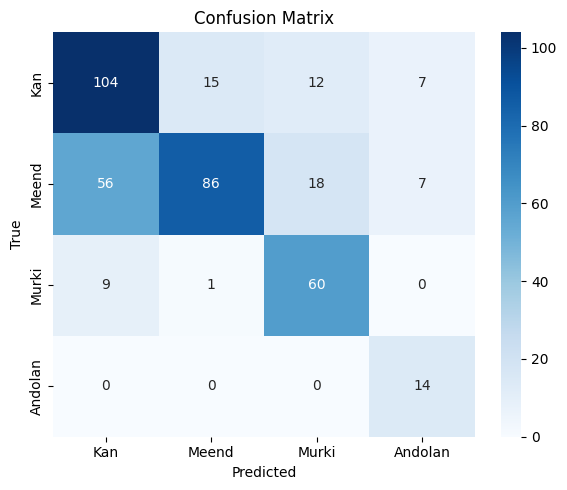

Precision: [0.61538462 0.84313725 0.66666667 0.5       ]
Recall:    [0.75362319 0.51497006 0.85714286 1.        ]
F1:        [0.67752443 0.6394052  0.75       0.66666667]


In [34]:
all_preds, all_labels, precision, recall, f1 = evaluate_model(model, test_loader, label_map)

# Print as arrays
print("Precision:", precision)
print("Recall:   ", recall)
print("F1:       ", f1)

#### Without data augmentation 

##### loss:0.9083, trainacc = 0.643, testacc = 0.589
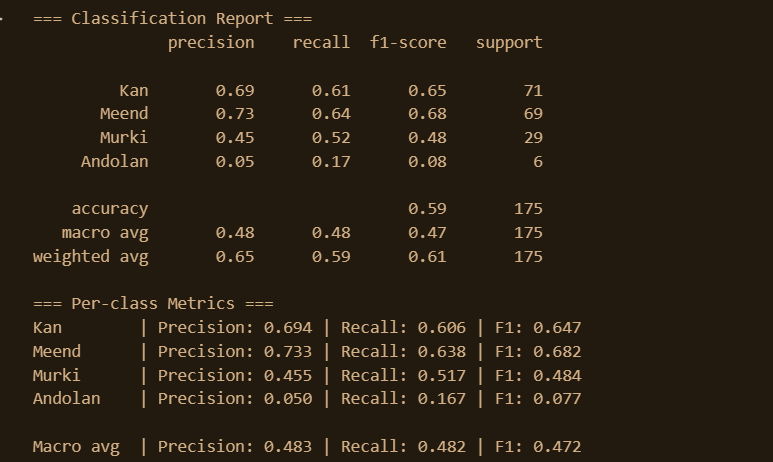

#### Cross validation for augmented data

In [37]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

def cross_validate_tcn(X, y, label_map, n_splits=5, epochs=30, batch_size=16):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    idx_to_label = {v: k for k, v in label_map.items()}
    target_names = [idx_to_label[i] for i in range(len(label_map))]
    
    fold_results = []
    
    for fold, (train_idx, test_idx) in enumerate(skf.split(X.reshape(len(X), -1), y)):
        print(f"\n{'='*50}")
        print(f"FOLD {fold+1}/{n_splits}")
        print(f"{'='*50}")
        
        # Split using indices directly on numpy arrays
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Use TensorDataset like your get_dataloaders
        train_ds = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
        test_ds  = TensorDataset(torch.tensor(X_test),  torch.tensor(y_test))
        
        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        test_loader  = DataLoader(test_ds,  batch_size=batch_size)
        
        # Train
        model = train_tcn(train_loader, test_loader,
                          num_classes=len(label_map), epochs=epochs)
        
        # Evaluate
        print(f"\n--- Fold {fold+1} Evaluation ---")
        all_preds, all_labels, precision, recall, f1 = evaluate_model(
            model, test_loader, label_map
        )
        
        acc    = (all_preds == all_labels).mean()
        f1_mac = f1.mean()
        
        fold_results.append({
            "fold": fold + 1,
            "accuracy": acc,
            "macro_f1": f1_mac,
            "precision": precision,
            "recall": recall,
            "per_class_f1": f1,
            "all_preds": all_preds,
            "all_labels": all_labels
        })
    
    # Summary
    print(f"\n{'='*50}")
    print("CROSS VALIDATION SUMMARY")
    print(f"{'='*50}")
    
    accs = [r['accuracy'] for r in fold_results]
    f1s  = [r['macro_f1'] for r in fold_results]
    print(f"\nAccuracy: {np.mean(accs):.3f} ± {np.std(accs):.3f}")
    print(f"Macro F1: {np.mean(f1s):.3f} ± {np.std(f1s):.3f}")
    
    print("\nPer-class metrics across folds (mean ± std):")
    print(f"{'Class':10s} | {'Precision':>15s} | {'Recall':>15s} | {'F1':>15s}")
    print("-" * 65)
    for i, name in enumerate(target_names):
        prec_scores = [r['precision'][i]    for r in fold_results]
        rec_scores  = [r['recall'][i]       for r in fold_results]
        f1_scores   = [r['per_class_f1'][i] for r in fold_results]
        print(f"{name:10s} | "
              f"{np.mean(prec_scores):.3f} ± {np.std(prec_scores):.3f}  | "
              f"{np.mean(rec_scores):.3f} ± {np.std(rec_scores):.3f}  | "
              f"{np.mean(f1_scores):.3f} ± {np.std(f1_scores):.3f}")
    
    # Combined confusion matrix
    all_preds_combined  = np.concatenate([r['all_preds']  for r in fold_results])
    all_labels_combined = np.concatenate([r['all_labels'] for r in fold_results])
    
    cm = confusion_matrix(all_labels_combined, all_preds_combined)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names,
                yticklabels=target_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Combined Confusion Matrix (all folds)")
    plt.tight_layout()
    plt.show()
    
    return fold_results

X shape: (1941, 1, 117)
y shape: (1941,)
Skipped: 0
Label distribution: {'Kan': 687, 'Meend': 834, 'Murki': 348, 'Andolan': 72}

FOLD 1/5
Epoch 01 | Loss: 1.4327 | Train Acc: 0.329 | Test Acc: 0.545
Epoch 02 | Loss: 1.2250 | Train Acc: 0.474 | Test Acc: 0.530
Epoch 03 | Loss: 1.2021 | Train Acc: 0.496 | Test Acc: 0.537
Epoch 04 | Loss: 1.1670 | Train Acc: 0.519 | Test Acc: 0.527
Epoch 05 | Loss: 1.1408 | Train Acc: 0.535 | Test Acc: 0.532
Epoch 06 | Loss: 1.1022 | Train Acc: 0.544 | Test Acc: 0.530
Epoch 07 | Loss: 1.1101 | Train Acc: 0.550 | Test Acc: 0.463
Epoch 08 | Loss: 1.0787 | Train Acc: 0.558 | Test Acc: 0.560
Epoch 09 | Loss: 1.0385 | Train Acc: 0.579 | Test Acc: 0.589
Epoch 10 | Loss: 1.0288 | Train Acc: 0.575 | Test Acc: 0.530
Epoch 11 | Loss: 1.0202 | Train Acc: 0.575 | Test Acc: 0.627
Epoch 12 | Loss: 0.9721 | Train Acc: 0.595 | Test Acc: 0.622
Epoch 13 | Loss: 0.9493 | Train Acc: 0.622 | Test Acc: 0.638
Epoch 14 | Loss: 0.9594 | Train Acc: 0.617 | Test Acc: 0.591
Epoch 15

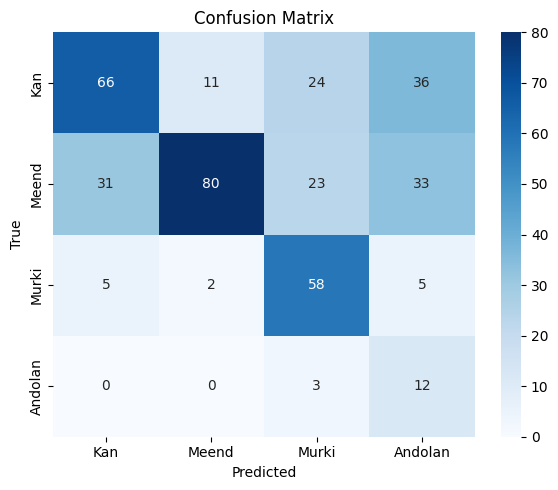


FOLD 2/5
Epoch 01 | Loss: 1.3657 | Train Acc: 0.415 | Test Acc: 0.518
Epoch 02 | Loss: 1.2318 | Train Acc: 0.505 | Test Acc: 0.433
Epoch 03 | Loss: 1.2173 | Train Acc: 0.473 | Test Acc: 0.575
Epoch 04 | Loss: 1.1846 | Train Acc: 0.521 | Test Acc: 0.523
Epoch 05 | Loss: 1.1584 | Train Acc: 0.495 | Test Acc: 0.549
Epoch 06 | Loss: 1.1690 | Train Acc: 0.527 | Test Acc: 0.585
Epoch 07 | Loss: 1.1217 | Train Acc: 0.526 | Test Acc: 0.588
Epoch 08 | Loss: 1.0986 | Train Acc: 0.560 | Test Acc: 0.575
Epoch 09 | Loss: 1.0863 | Train Acc: 0.543 | Test Acc: 0.559
Epoch 10 | Loss: 1.0866 | Train Acc: 0.536 | Test Acc: 0.631
Epoch 11 | Loss: 1.0575 | Train Acc: 0.577 | Test Acc: 0.526
Epoch 12 | Loss: 0.9964 | Train Acc: 0.585 | Test Acc: 0.606
Epoch 13 | Loss: 0.9928 | Train Acc: 0.601 | Test Acc: 0.575
Epoch 14 | Loss: 0.9845 | Train Acc: 0.579 | Test Acc: 0.647
Epoch 15 | Loss: 0.9416 | Train Acc: 0.613 | Test Acc: 0.603
Epoch 16 | Loss: 0.9477 | Train Acc: 0.601 | Test Acc: 0.549
Epoch 17 | Los

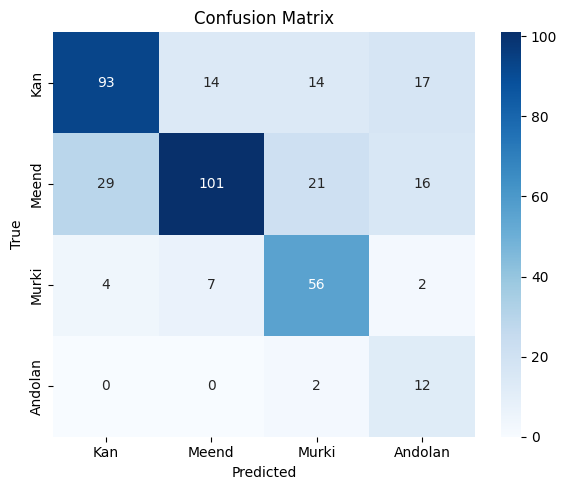


FOLD 3/5
Epoch 01 | Loss: 1.2716 | Train Acc: 0.466 | Test Acc: 0.495
Epoch 02 | Loss: 1.1938 | Train Acc: 0.540 | Test Acc: 0.518
Epoch 03 | Loss: 1.1723 | Train Acc: 0.520 | Test Acc: 0.564
Epoch 04 | Loss: 1.1525 | Train Acc: 0.541 | Test Acc: 0.260
Epoch 05 | Loss: 1.1445 | Train Acc: 0.535 | Test Acc: 0.531
Epoch 06 | Loss: 1.1091 | Train Acc: 0.551 | Test Acc: 0.508
Epoch 07 | Loss: 1.0886 | Train Acc: 0.570 | Test Acc: 0.557
Epoch 08 | Loss: 1.0435 | Train Acc: 0.578 | Test Acc: 0.505
Epoch 09 | Loss: 1.0727 | Train Acc: 0.575 | Test Acc: 0.487
Epoch 10 | Loss: 1.0395 | Train Acc: 0.585 | Test Acc: 0.554
Epoch 11 | Loss: 1.0050 | Train Acc: 0.570 | Test Acc: 0.541
Epoch 12 | Loss: 1.0041 | Train Acc: 0.605 | Test Acc: 0.521
Epoch 13 | Loss: 0.9937 | Train Acc: 0.589 | Test Acc: 0.505
Epoch 14 | Loss: 0.9423 | Train Acc: 0.621 | Test Acc: 0.564
Epoch 15 | Loss: 0.9181 | Train Acc: 0.622 | Test Acc: 0.637
Epoch 16 | Loss: 0.9385 | Train Acc: 0.621 | Test Acc: 0.557
Epoch 17 | Los

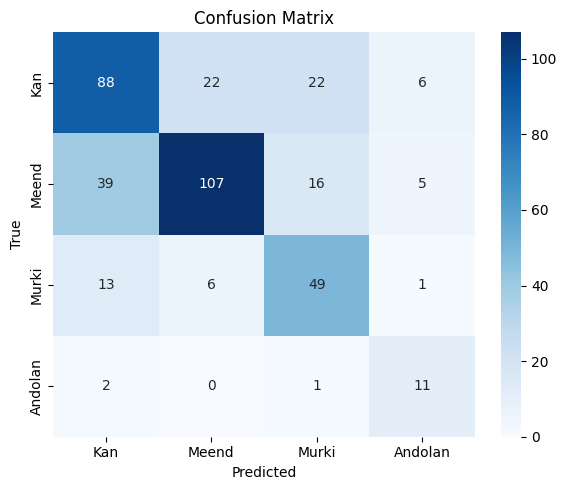


FOLD 4/5
Epoch 01 | Loss: 1.2816 | Train Acc: 0.482 | Test Acc: 0.443
Epoch 02 | Loss: 1.1941 | Train Acc: 0.476 | Test Acc: 0.487
Epoch 03 | Loss: 1.1786 | Train Acc: 0.537 | Test Acc: 0.534
Epoch 04 | Loss: 1.1562 | Train Acc: 0.517 | Test Acc: 0.567
Epoch 05 | Loss: 1.1159 | Train Acc: 0.542 | Test Acc: 0.567
Epoch 06 | Loss: 1.1123 | Train Acc: 0.538 | Test Acc: 0.420
Epoch 07 | Loss: 1.0442 | Train Acc: 0.574 | Test Acc: 0.564
Epoch 08 | Loss: 1.0296 | Train Acc: 0.581 | Test Acc: 0.443
Epoch 09 | Loss: 1.0205 | Train Acc: 0.591 | Test Acc: 0.513
Epoch 10 | Loss: 0.9963 | Train Acc: 0.599 | Test Acc: 0.446
Epoch 11 | Loss: 0.9788 | Train Acc: 0.594 | Test Acc: 0.577
Epoch 12 | Loss: 0.9498 | Train Acc: 0.610 | Test Acc: 0.570
Epoch 13 | Loss: 0.9277 | Train Acc: 0.619 | Test Acc: 0.534
Epoch 14 | Loss: 0.8677 | Train Acc: 0.625 | Test Acc: 0.590
Epoch 15 | Loss: 0.9017 | Train Acc: 0.622 | Test Acc: 0.582
Epoch 16 | Loss: 0.8775 | Train Acc: 0.626 | Test Acc: 0.541
Epoch 17 | Los

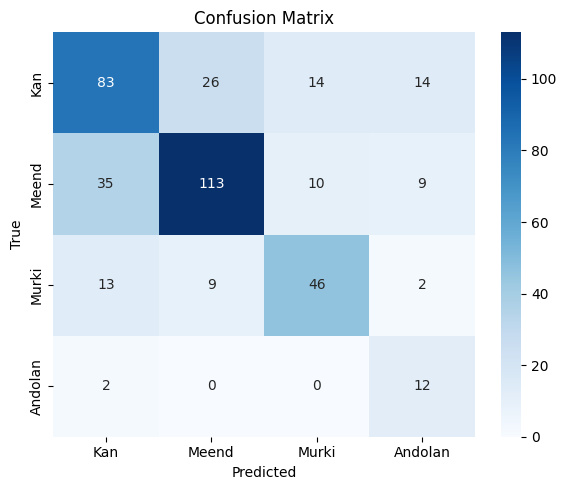


FOLD 5/5
Epoch 01 | Loss: 1.3410 | Train Acc: 0.359 | Test Acc: 0.461
Epoch 02 | Loss: 1.2371 | Train Acc: 0.494 | Test Acc: 0.554
Epoch 03 | Loss: 1.2050 | Train Acc: 0.484 | Test Acc: 0.601
Epoch 04 | Loss: 1.1997 | Train Acc: 0.459 | Test Acc: 0.554
Epoch 05 | Loss: 1.1433 | Train Acc: 0.522 | Test Acc: 0.616
Epoch 06 | Loss: 1.1235 | Train Acc: 0.531 | Test Acc: 0.595
Epoch 07 | Loss: 1.1163 | Train Acc: 0.540 | Test Acc: 0.593
Epoch 08 | Loss: 1.0694 | Train Acc: 0.543 | Test Acc: 0.675
Epoch 09 | Loss: 1.1198 | Train Acc: 0.535 | Test Acc: 0.474
Epoch 10 | Loss: 1.0358 | Train Acc: 0.558 | Test Acc: 0.611
Epoch 11 | Loss: 1.0744 | Train Acc: 0.547 | Test Acc: 0.577
Epoch 12 | Loss: 1.0361 | Train Acc: 0.565 | Test Acc: 0.652
Epoch 13 | Loss: 0.9955 | Train Acc: 0.564 | Test Acc: 0.691
Epoch 14 | Loss: 0.9909 | Train Acc: 0.581 | Test Acc: 0.693
Epoch 15 | Loss: 0.9976 | Train Acc: 0.602 | Test Acc: 0.631
Epoch 16 | Loss: 0.9279 | Train Acc: 0.598 | Test Acc: 0.714
Epoch 17 | Los

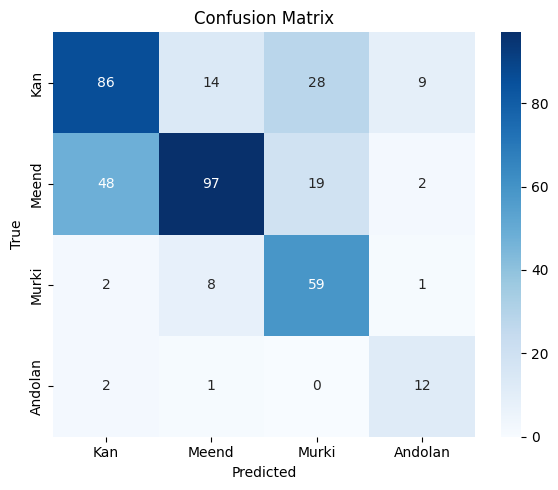


CROSS VALIDATION SUMMARY

Accuracy: 0.639 ± 0.043
Macro F1: 0.608 ± 0.048

Per-class metrics across folds (mean ± std):
Class      |       Precision |          Recall |              F1
-----------------------------------------------------------------
Kan        | 0.650 ± 0.045  | 0.605 ± 0.066  | 0.625 ± 0.048
Meend      | 0.811 ± 0.033  | 0.597 ± 0.067  | 0.684 ± 0.037
Murki      | 0.582 ± 0.043  | 0.770 ± 0.073  | 0.659 ± 0.022
Andolan    | 0.339 ± 0.136  | 0.820 ± 0.031  | 0.462 ± 0.139


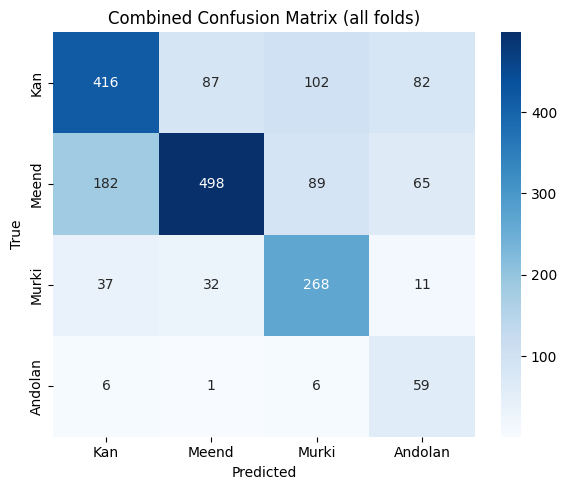

In [38]:
X, y, label_map = prepare_tcn_input(segments_aug, fixed_length=117)
fold_results = cross_validate_tcn(X, y, label_map, n_splits=5, epochs=30)

### Adaptive window

In [5]:
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
def prepare_tcn_input(segments, min_length=20):
    label_map = {"Kan": 0, "Meend": 1, "Murki": 2, "Andolan": 3}
    
    X, y = [], []
    skipped = 0
    
    # Filter too short
    segments = [s for s in segments if len(s['pitch_curve']) >= min_length]
    
    for seg in segments:
        curve = seg['pitch_curve'].copy()
        label = seg['label']
        
        if label not in label_map:
            skipped += 1
            continue
        
        # Normalize
        if curve.std() > 0:
            curve = (curve - curve.mean()) / curve.std()
        else:
            skipped += 1
            continue
        
        X.append(torch.tensor(curve, dtype=torch.float32).unsqueeze(0))  # (1, length)
        y.append(label_map[label])
    
    y = torch.tensor(y, dtype=torch.int64)
    
    print(f"Total segments: {len(X)}")
    print(f"Skipped: {skipped}")
    print(f"Label distribution: { {k: int((y==v).sum()) for k,v in label_map.items()} }")
    
    return X, y, label_map  # X is now a list of variable length tensors

In [6]:
from torch.nn.utils.rnn import pad_sequence

def collate_fn(batch):
    """Pads sequences in each batch to the longest in that batch."""
    X_batch, y_batch = zip(*batch)
    lengths = torch.tensor([x.shape[-1] for x in X_batch])
    
    # Pad to longest sequence in this batch
    X_padded = pad_sequence(
        [x.squeeze(0) for x in X_batch], 
        batch_first=True
    ).unsqueeze(1)  # (batch, 1, max_len_in_batch)
    
    return X_padded, torch.tensor(y_batch), lengths

In [7]:
from torch.utils.data import Dataset

class OrnamentDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def get_dataloaders(X, y, batch_size=16, test_size=0.2):
    # Split indices
    from sklearn.model_selection import train_test_split
    indices = list(range(len(X)))
    train_idx, test_idx = train_test_split(
        indices, test_size=test_size, 
        stratify=y.numpy(), random_state=42
    )
    
    X_train = [X[i] for i in train_idx]
    X_test  = [X[i] for i in test_idx]
    y_train = y[train_idx]
    y_test  = y[test_idx]
    
    train_ds = OrnamentDataset(X_train, y_train)
    test_ds  = OrnamentDataset(X_test,  y_test)
    
    train_loader = DataLoader(train_ds, batch_size=batch_size, 
                              shuffle=True, collate_fn=collate_fn)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, 
                              collate_fn=collate_fn)
    
    print(f"Train: {len(train_ds)} | Test: {len(test_ds)}")
    return train_loader, test_loader

In [9]:
import torch.nn as nn

class ResidualBlock(nn.Module):
    def __init__(self, channels, kernel_size, dilation):
        super().__init__()
        padding = (kernel_size - 1) * dilation
        self.conv1 = nn.Conv1d(channels, channels, kernel_size, dilation=dilation, padding=padding)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size, dilation=dilation, padding=padding)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        self.norm1 = nn.BatchNorm1d(channels)
        self.norm2 = nn.BatchNorm1d(channels)

    def forward(self, x):
        out = self.relu(self.norm1(self.conv1(x)[:, :, :x.size(2)]))
        out = self.dropout(out)
        out = self.relu(self.norm2(self.conv2(out)[:, :, :x.size(2)]))
        return self.relu(out + x)  # residual connection

class OrnamentTCN(nn.Module):
    def __init__(self, input_size=1, num_classes=4, channels=32, kernel_size=3):
        super().__init__()
        self.input_proj = nn.Conv1d(input_size, channels, kernel_size=1)
        self.tcn = nn.Sequential(
            ResidualBlock(channels, kernel_size, dilation=1),
            ResidualBlock(channels, kernel_size, dilation=2),
            ResidualBlock(channels, kernel_size, dilation=4),
            ResidualBlock(channels, kernel_size, dilation=8),
        )
        self.adaptive_pool = nn.AdaptiveAvgPool1d(1)  # handles any length
        self.classifier = nn.Linear(channels, num_classes)

    def forward(self, x):
        out = self.input_proj(x)
        out = self.tcn(out)
        out = self.adaptive_pool(out).squeeze(-1)  # (batch, channels)
        return self.classifier(out)

In [18]:
from sklearn.utils.class_weight import compute_class_weight

def train_tcn(train_loader, test_loader, num_classes=4, epochs=30):
    model = OrnamentTCN(input_size=1, num_classes=num_classes)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    
    # Handle class imbalance
    all_labels = train_loader.dataset.y.numpy()
    weights = compute_class_weight('balanced', classes=np.unique(all_labels), y=all_labels)
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float))
    
    for epoch in range(epochs):
        model.train()
        train_loss, correct, total = 0, 0, 0
        for xb, yb, lengths in train_loader:  # unpack lengths too
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            correct += (preds.argmax(1) == yb).sum().item()
            total += len(yb)
        # Evaluate
        model.eval()
        test_correct, test_total = 0, 0
        with torch.no_grad():
            for xb, yb, lengths in test_loader:
                preds = model(xb)
                test_correct += (preds.argmax(1) == yb).sum().item()
                test_total += len(yb)
        
        print(f"Epoch {epoch+1:02d} | "
              f"Loss: {train_loss/len(train_loader):.4f} | "
              f"Train Acc: {correct/total:.3f} | "
              f"Test Acc: {test_correct/test_total:.3f}")
    
    return model

In [19]:
X, y, label_map = prepare_tcn_input(segments, min_length=20)
train_loader, test_loader = get_dataloaders(X, y, batch_size=16)
model = train_tcn(train_loader, test_loader, epochs=30)

Total segments: 647
Skipped: 0
Label distribution: {'Kan': 229, 'Meend': 278, 'Murki': 116, 'Andolan': 24}
Train: 517 | Test: 130
Epoch 01 | Loss: 1.3880 | Train Acc: 0.400 | Test Acc: 0.554
Epoch 02 | Loss: 1.2953 | Train Acc: 0.505 | Test Acc: 0.477
Epoch 03 | Loss: 1.2842 | Train Acc: 0.551 | Test Acc: 0.423
Epoch 04 | Loss: 1.2671 | Train Acc: 0.497 | Test Acc: 0.315
Epoch 05 | Loss: 1.2869 | Train Acc: 0.532 | Test Acc: 0.531
Epoch 06 | Loss: 1.2575 | Train Acc: 0.515 | Test Acc: 0.515
Epoch 07 | Loss: 1.2739 | Train Acc: 0.549 | Test Acc: 0.346
Epoch 08 | Loss: 1.2476 | Train Acc: 0.480 | Test Acc: 0.515
Epoch 09 | Loss: 1.2527 | Train Acc: 0.559 | Test Acc: 0.485
Epoch 10 | Loss: 1.2589 | Train Acc: 0.542 | Test Acc: 0.508
Epoch 11 | Loss: 1.2351 | Train Acc: 0.561 | Test Acc: 0.508
Epoch 12 | Loss: 1.2446 | Train Acc: 0.573 | Test Acc: 0.492
Epoch 13 | Loss: 1.2239 | Train Acc: 0.557 | Test Acc: 0.515
Epoch 14 | Loss: 1.2095 | Train Acc: 0.565 | Test Acc: 0.492
Epoch 15 | Loss:

=== Classification Report ===
              precision    recall  f1-score   support

         Kan       0.60      0.59      0.59        46
       Meend       0.72      0.46      0.57        56
       Murki       0.54      0.65      0.59        23
     Andolan       0.05      0.20      0.08         5

    accuracy                           0.53       130
   macro avg       0.48      0.48      0.46       130
weighted avg       0.62      0.53      0.56       130

=== Per-class Metrics ===
Kan        | Precision: 0.600 | Recall: 0.587 | F1: 0.593
Meend      | Precision: 0.722 | Recall: 0.464 | F1: 0.565
Murki      | Precision: 0.536 | Recall: 0.652 | F1: 0.588
Andolan    | Precision: 0.048 | Recall: 0.200 | F1: 0.077

Macro avg  | Precision: 0.476 | Recall: 0.476 | F1: 0.456


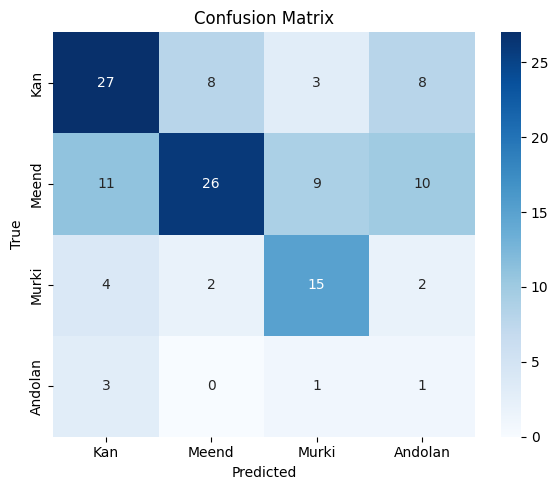

Precision: [0.6        0.72222222 0.53571429 0.04761905]
Recall:    [0.58695652 0.46428571 0.65217391 0.2       ]
F1:        [0.59340659 0.56521739 0.58823529 0.07692308]


In [24]:
all_preds, all_labels, precision, recall, f1 = evaluate_model(model, test_loader, label_map)

# Print as arrays
print("Precision:", precision)
print("Recall:   ", recall)
print("F1:       ", f1)